In [ ]:
#pymsql

In [4]:
import mysql.connector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#connect to server
cnx = mysql.connector.connect(
    host = "127.0.0.1",
    port = 3305,
    user = "root",
    password = "palak@21"
)

In [5]:
#FETCH DATA FROM MYSQL
query = "SELECT * FROM banking_case.customer"
df = pd.read_sql(query, cnx)

C:\Users\palak\AppData\Local\Temp\ipykernel_9156\1337440229.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


In [6]:
#Closing the mysql connection
cnx.close()

In [7]:
#view data
print(df)
df.head()

     ï»¿Client ID              Name  Age  Location ID Joined Bank  \
0        IND81288     Raymond Mills   24        34324  06-05-2019   
1        IND65833     Julia Spencer   23        42205  10-12-2001   
2        IND47499    Stephen Murray   27         7314  25-01-2010   
3        IND72498    Virginia Garza   40        34594  28-03-2019   
4        IND60181   Melissa Sanders   46        41269  20-07-2012   
...           ...               ...  ...          ...         ...   
2995     IND66827         Earl Hall   82         8760  09-10-2014   
2996     IND40556  Billy Williamson   44        32837  05-02-2009   
2997     IND72414      Victor Black   70        36088  29-12-2009   
2998     IND46652       Andrew Ford   56        24871  13-02-2006   
2999     IND40216        Amy Nguyen   79        38518  08-12-2005   

          Banking Contact Nationality                     Occupation  \
0          Anthony Torres    American           Safety Technician IV   
1        Jonathan Hawkins  

,ï»¿Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [8]:
#Exploratory Data Analysis
# Check number of rows and columns
df.shape

(3000, 25)

In [9]:
# Check structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ï»¿Client ID              3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [10]:
# Descriptive statistics
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [11]:
#Column names
df.columns

Index(['ï»¿Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

In [12]:
#Data types
df.dtypes

ï»¿Client ID                 object
Name                         object
Age                           int64
Location ID                   int64
Joined Bank                  object
Banking Contact              object
Nationality                  object
Occupation                   object
Fee Structure                object
Loyalty Classification       object
Estimated Income            float64
Superannuation Savings      float64
Amount of Credit Cards        int64
Credit Card Balance         float64
Bank Loans                  float64
Bank Deposits               float64
Checking Accounts           float64
Saving Accounts             float64
Foreign Currency Account    float64
Business Lending            float64
Properties Owned              int64
Risk Weighting                int64
BRId                          int64
GenderId                      int64
IAId                          int64
dtype: object

In [13]:
#Data Cleaning
# Check missing values in every column
missing_values = df.isnull().sum()
missing_values

ï»¿Client ID                0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [14]:
missing_values[missing_values > 0]

Series([], dtype: int64)

In [15]:
#Total Missing Values
df.isnull().sum().sum()

np.int64(0)

In [16]:
#Identifying numerical and categorical columns
numerical_cols_all = df.select_dtypes(include=np.number).columns

categorical_cols_all = df.select_dtypes(
    include=['object', 'category']
).columns

print("Numerical Columns:")
print(list(numerical_cols_all))

print("\nCategorical Columns:")
print(list(categorical_cols_all))

Numerical Columns:
['Age', 'Location ID', 'Estimated Income', 'Superannuation Savings', 'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending', 'Properties Owned', 'Risk Weighting', 'BRId', 'GenderId', 'IAId']

Categorical Columns:
['ï»¿Client ID', 'Name', 'Joined Bank', 'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure', 'Loyalty Classification']


In [18]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ï»¿Client ID              3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [20]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [21]:
#create income band
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Med', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)

In [22]:
#Check Income Band
df[['Estimated Income', 'Income Band']].head(10)

,Estimated Income,Income Band
0,75384.77,Low
1,289834.31,Med
2,169935.23,Med
3,356808.11,High
4,130711.68,Med
5,118326.96,Med
6,57336.47,Low
7,65125.80,Low
8,87849.47,Low
9,65369.36,Low


In [23]:
#Income Band frequency
df['Income Band'].value_counts()

Income Band
Med     1517
Low     1027
High     456
Name: count, dtype: int64

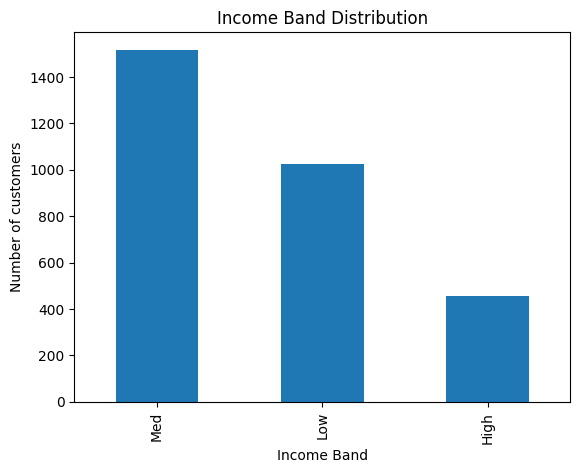

In [24]:
#Income band bar chart
df['Income Band'].value_counts().plot(kind='bar')
plt.title('Income Band Distribution')
plt.xlabel('Income Band')
plt.ylabel('Number of customers')

plt.show()

In [25]:
#Categorical Analysis
#Categorical columns
categorical_cols = df[["BRId","GenderId","IAId","Amount of Credit Cards","Nationality","Occupation","Fee Structure","Loyalty Classification","Properties Owned","Risk Weighting","Income Band"]].columns

print(list(categorical_cols))

['BRId', 'GenderId', 'IAId', 'Amount of Credit Cards', 'Nationality', 'Occupation', 'Fee Structure', 'Loyalty Classification', 'Properties Owned', 'Risk Weighting', 'Income Band']


In [26]:
#Value counts for categorical columns
for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    display(df[col].value_counts)



Value counts for 'BRId':


<bound method IndexOpsMixin.value_counts of 0       1
1       2
2       3
3       4
4       1
       ..
2995    3
2996    3
2997    3
2998    3
2999    3
Name: BRId, Length: 3000, dtype: int64>


Value counts for 'GenderId':


<bound method IndexOpsMixin.value_counts of 0       1
1       1
2       2
3       1
4       2
       ..
2995    2
2996    2
2997    2
2998    2
2999    2
Name: GenderId, Length: 3000, dtype: int64>


Value counts for 'IAId':


...

<bound method IndexOpsMixin.value_counts of 0       1
1       1
2       1
3       0
4       0
       ..
2995    1
2996    1
2997    2
2998    3
2999    1
Name: Properties Owned, Length: 3000, dtype: int64>


Value counts for 'Risk Weighting':


<bound method IndexOpsMixin.value_counts of 0       2
1       3
2       3
3       4
4       3
       ..
2995    3
2996    2
2997    2
2998    1
2999    1
Name: Risk Weighting, Length: 3000, dtype: int64>


Value counts for 'Income Band':


<bound method IndexOpsMixin.value_counts of 0        Low
1        Med
2        Med
3       High
4        Med
        ... 
2995     Med
2996     Low
2997     Low
2998     Med
2999     Low
Name: Income Band, Length: 3000, dtype: category
Categories (3, object): ['Low' < 'Med' < 'High']>

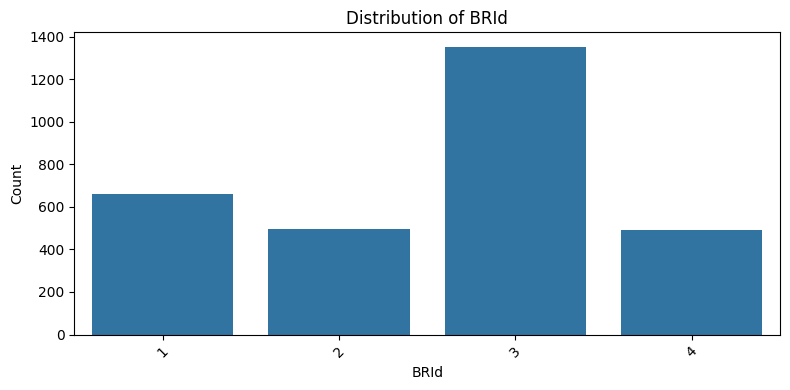

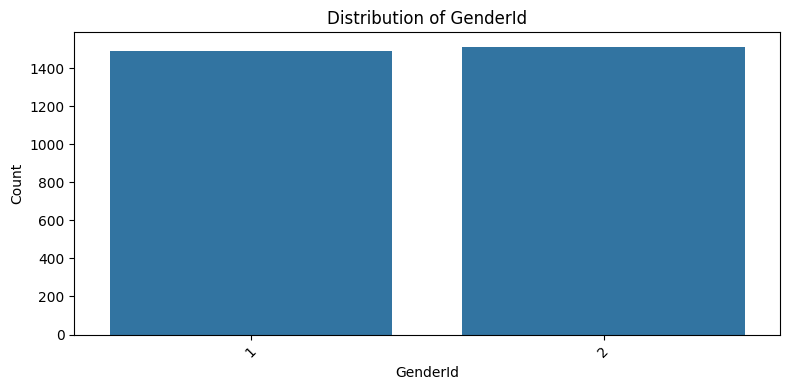

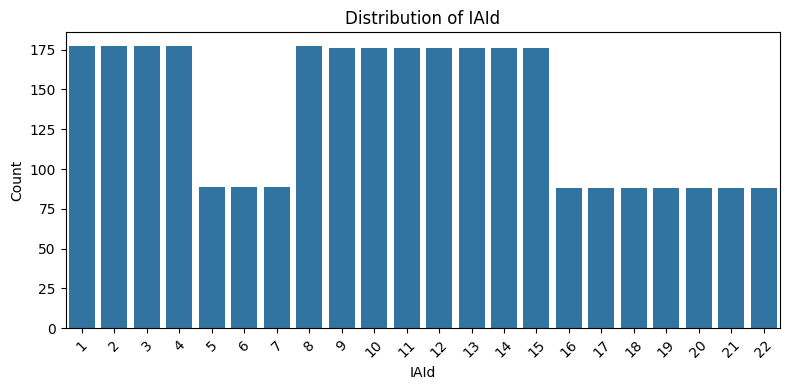

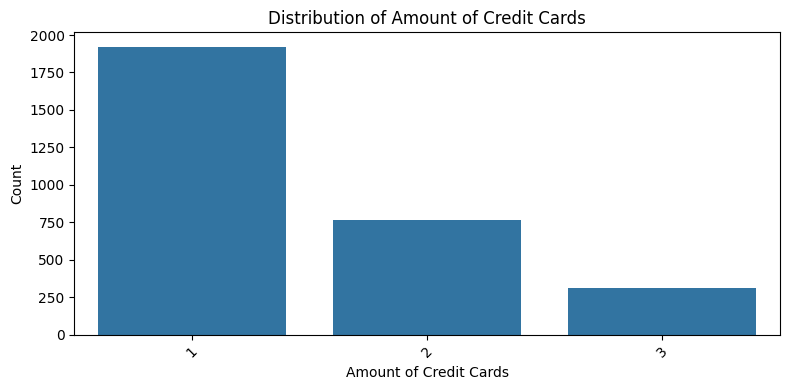

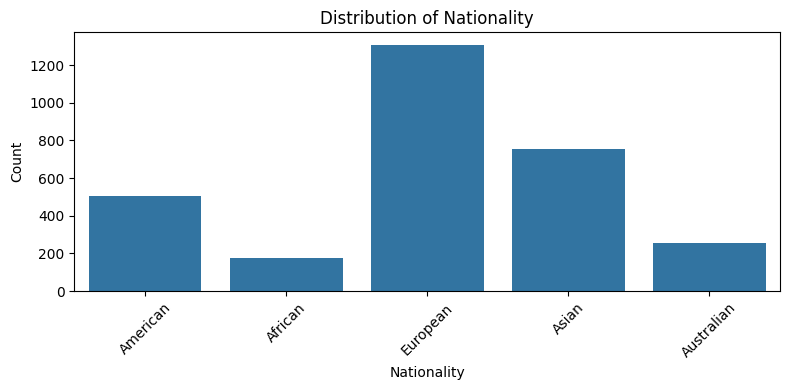

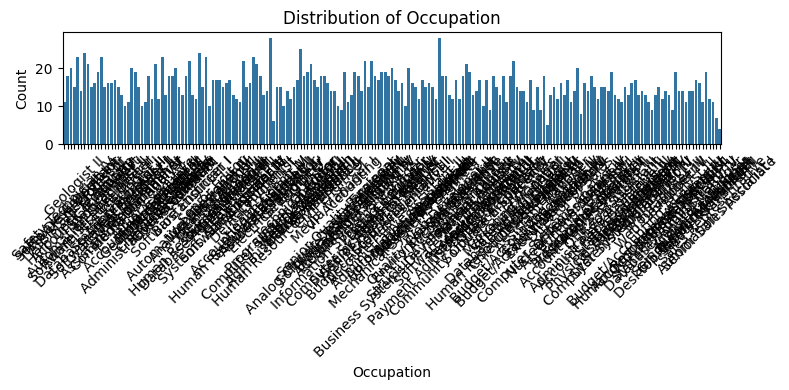

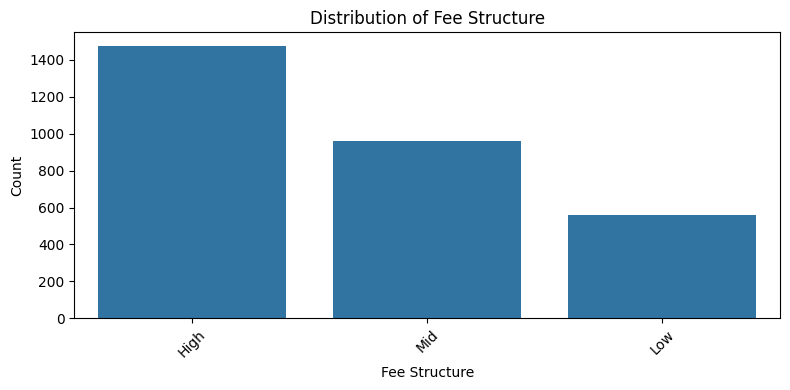

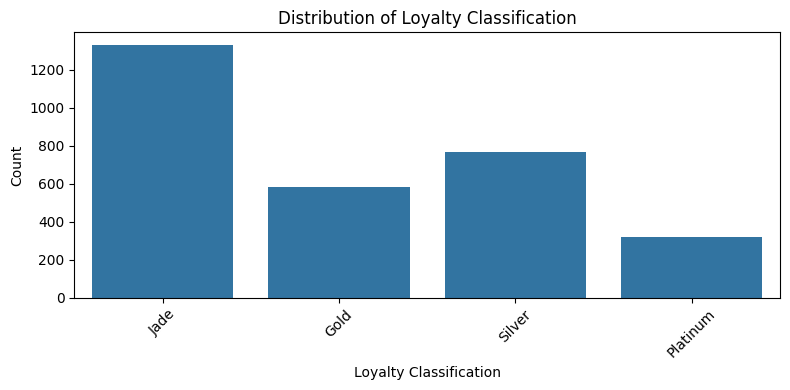

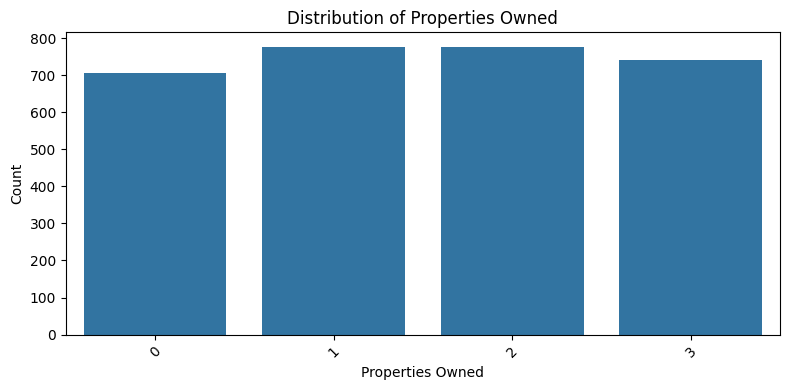

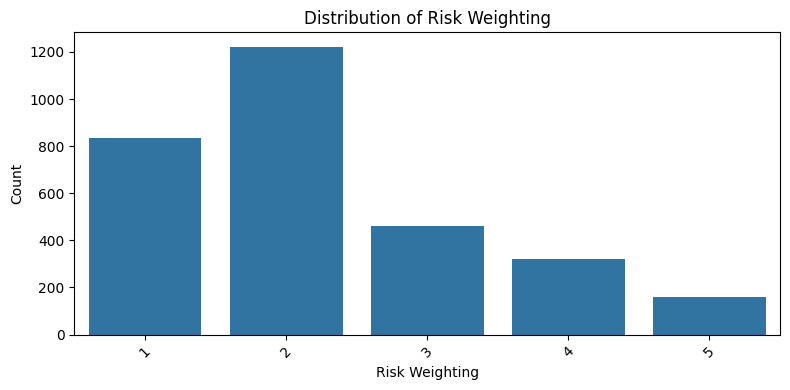

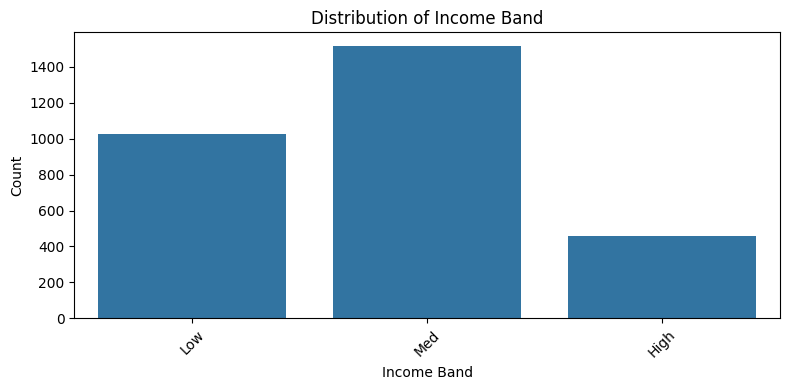

In [27]:
#Univariate analysis = analysis of one variable at a time.
for i, predictor in enumerate(categorical_cols):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=predictor)
    plt.title(f'Distribution of {predictor}')
    plt.xlabel(predictor)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

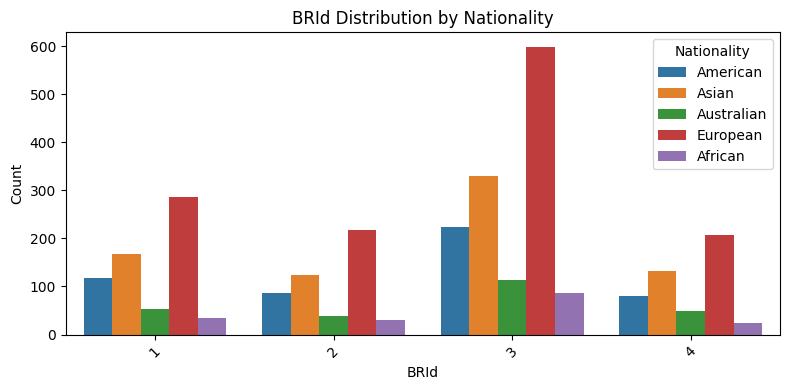

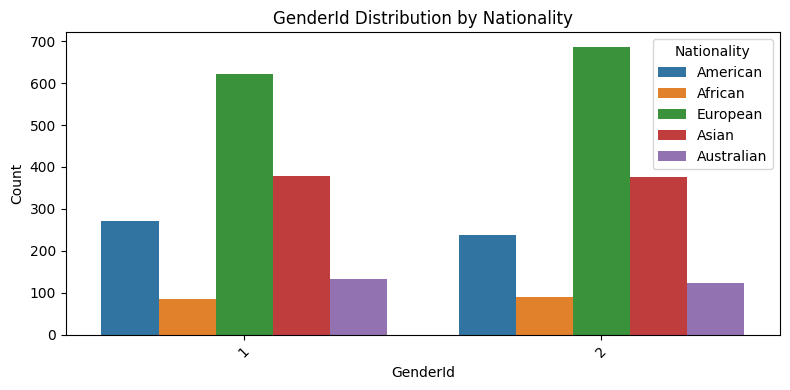

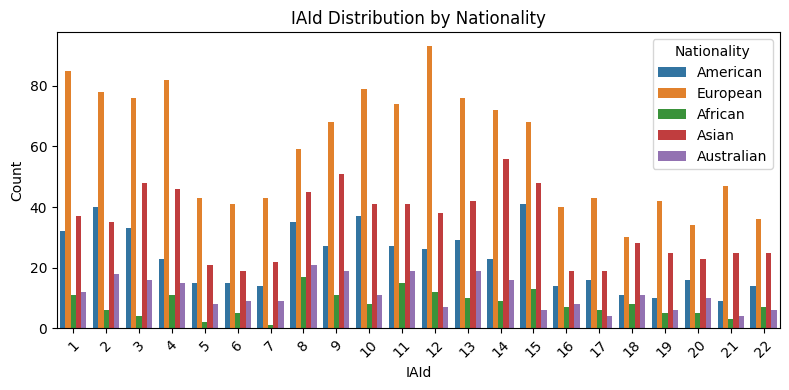

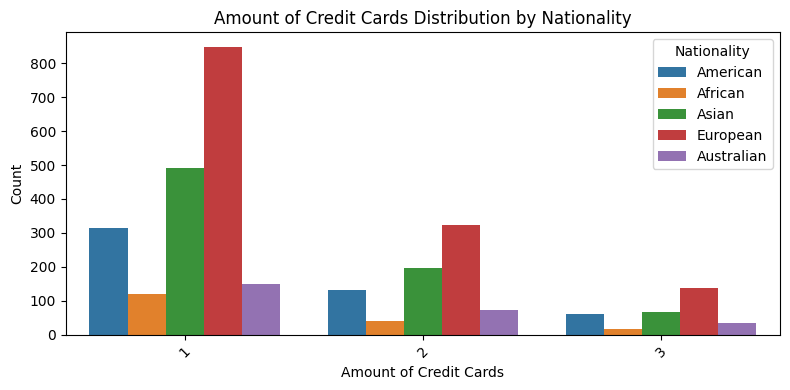

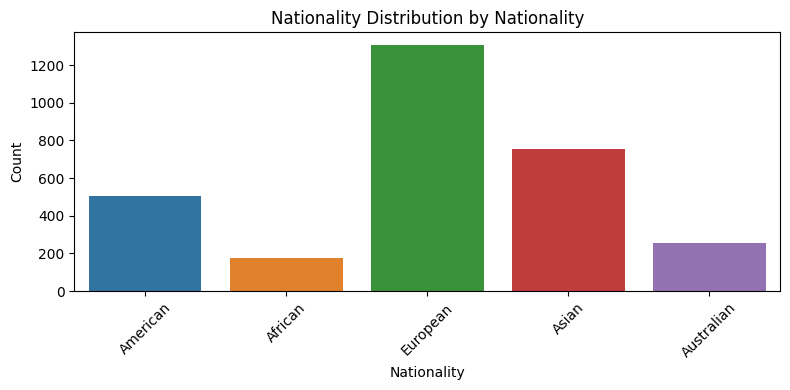

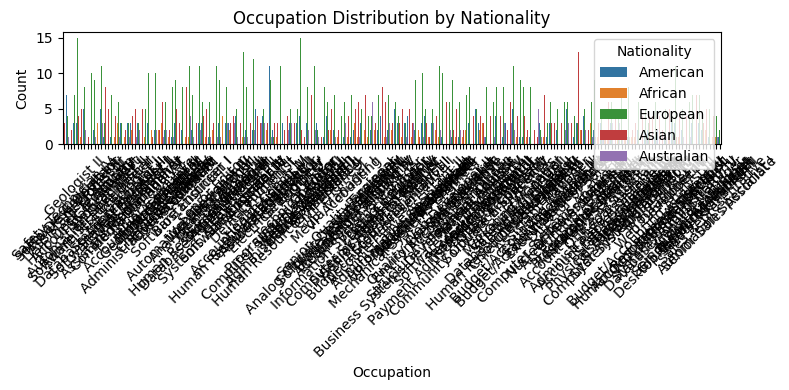

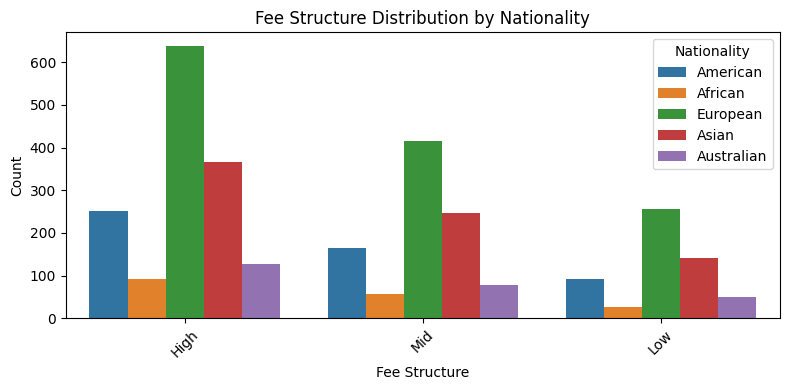

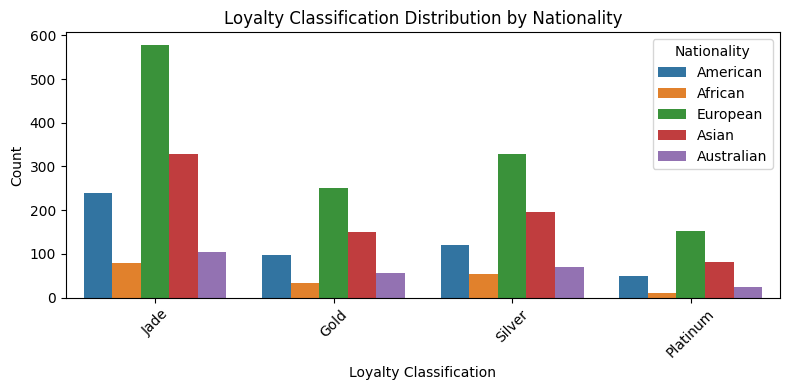

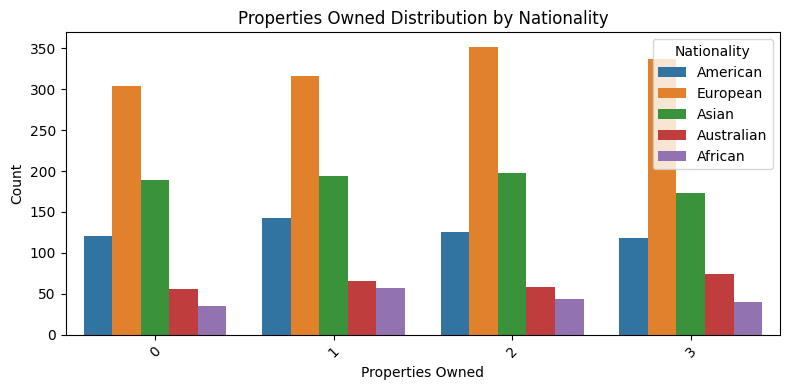

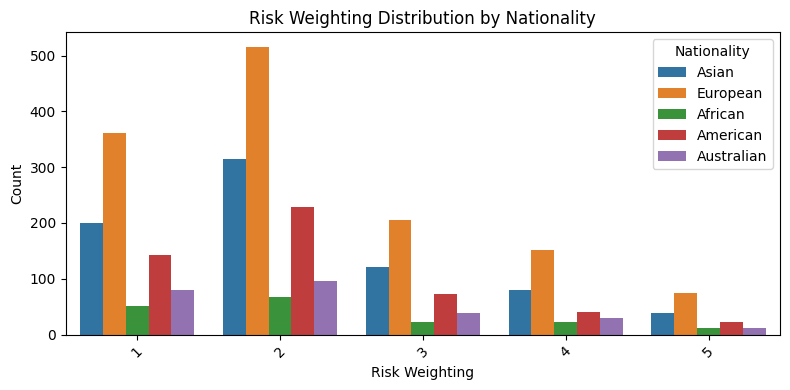

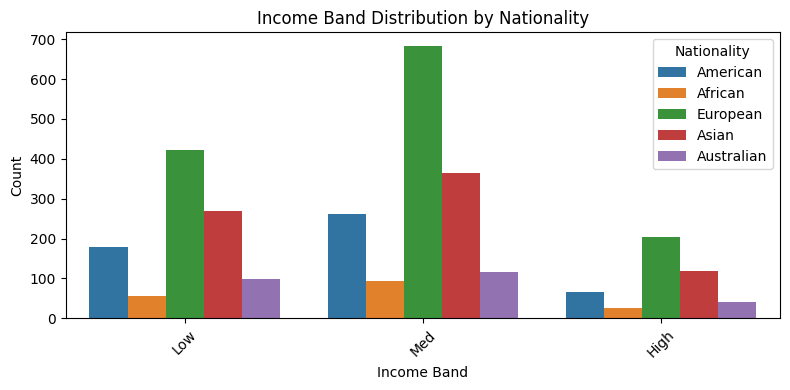

In [28]:
#Bivariate analysis
for i, predictor in enumerate(categorical_cols):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=predictor, hue='Nationality')
    plt.title(f'{predictor} Distribution by Nationality')
    plt.xlabel(predictor)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

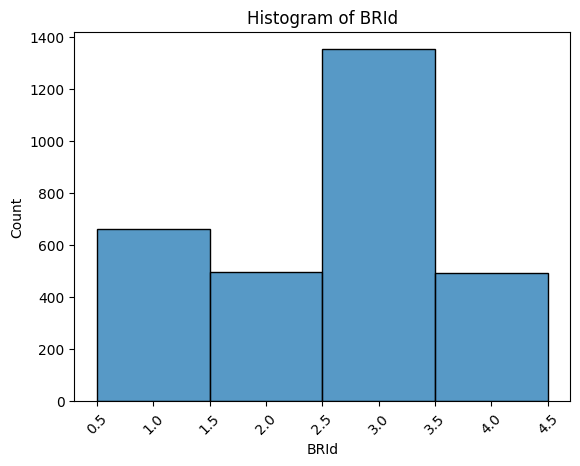

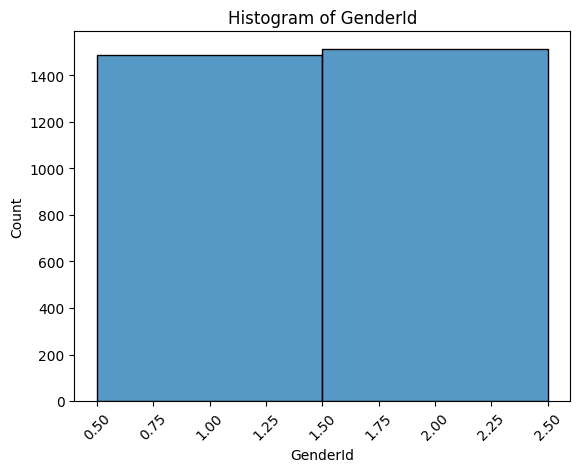

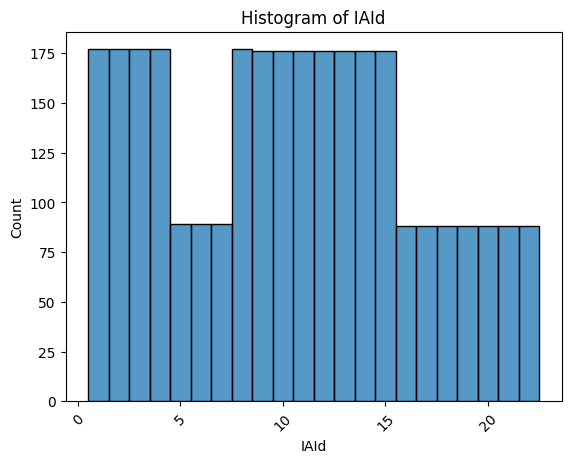

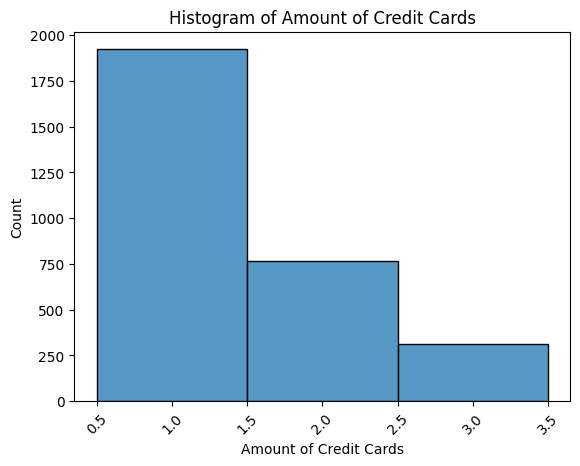

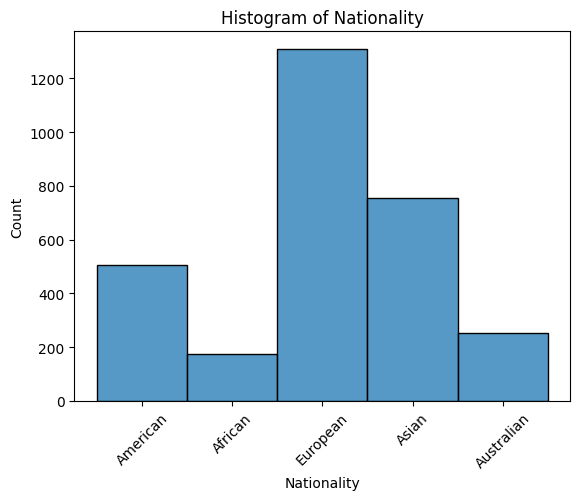

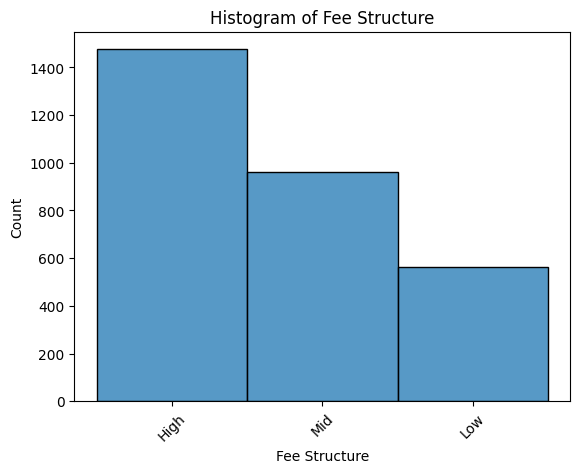

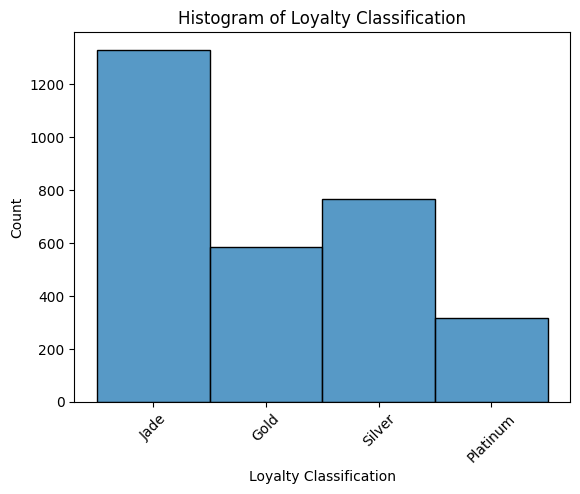

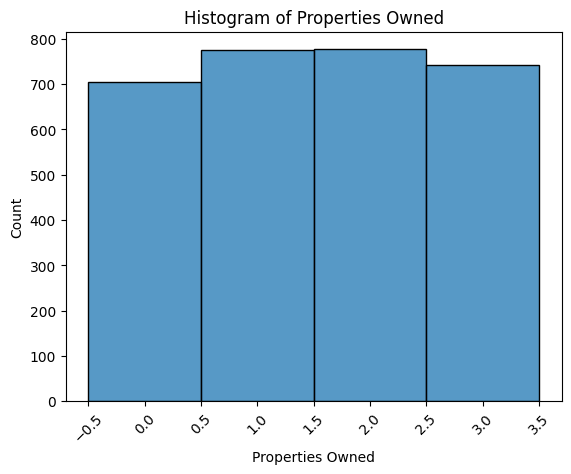

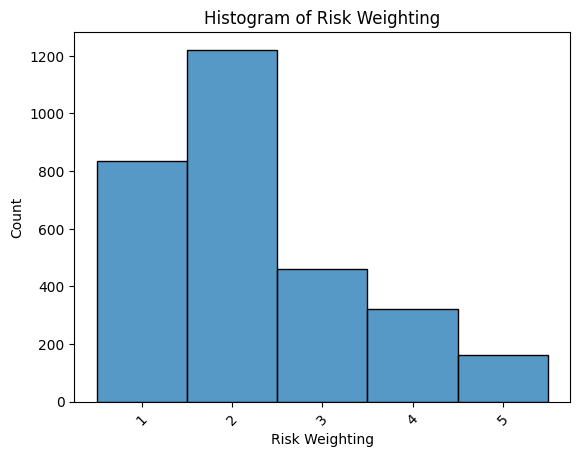

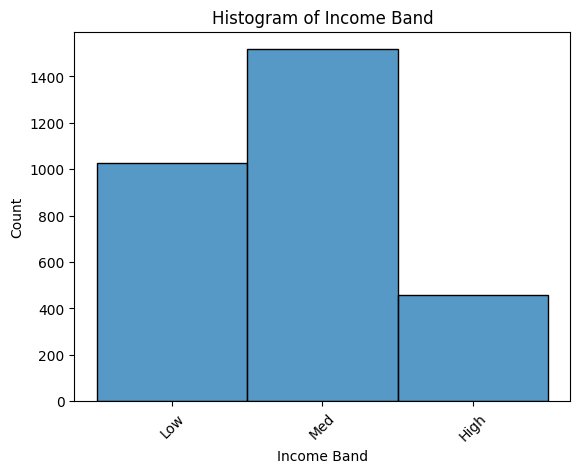

In [29]:
#Categorical Distribution
for col in categorical_cols:
    if col == "Occupation":
        continue
        plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, discrete=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [30]:
#Numerical columns
numerical_cols = ['Estimated Income','Superannuation Savings','Credit Card Balance','Bank Loans','Bank Deposits','Checking Accounts','Saving Accounts','Foreign Currency Account','Business Lending']

In [31]:
#check numerical columns
df[numerical_cols].head()

,Estimated Income,Superannuation Savings,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending
0,75384.77,17677.95,484.54,776242.92,1485828.64,603617.88,607332.46,12249.96,1134475.30
1,289834.31,17398.92,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.10
2,169935.23,42825.90,4568.74,1052715.84,1033401.59,652674.69,203054.35,79071.78,548137.58
3,356808.11,5473.15,4205.00,121195.06,1048157.49,1048157.49,234685.02,57513.65,1148402.29
4,130711.68,48077.60,3779.49,1048301.95,487782.53,446644.25,128351.45,30012.14,1674412.12


In [32]:
#Numerical Descriptive Statistics
df[numerical_cols].describe()

,Estimated Income,Superannuation Savings,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending
count,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03
mean,171305.034263,25531.599673,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05
std,111935.808209,16259.950770,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05
min,15919.480000,1482.030000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00
25%,82906.595000,12513.775000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05
50%,142313.480000,22357.355000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05
75%,242290.305000,35464.740000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06
max,522330.260000,75963.900000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06


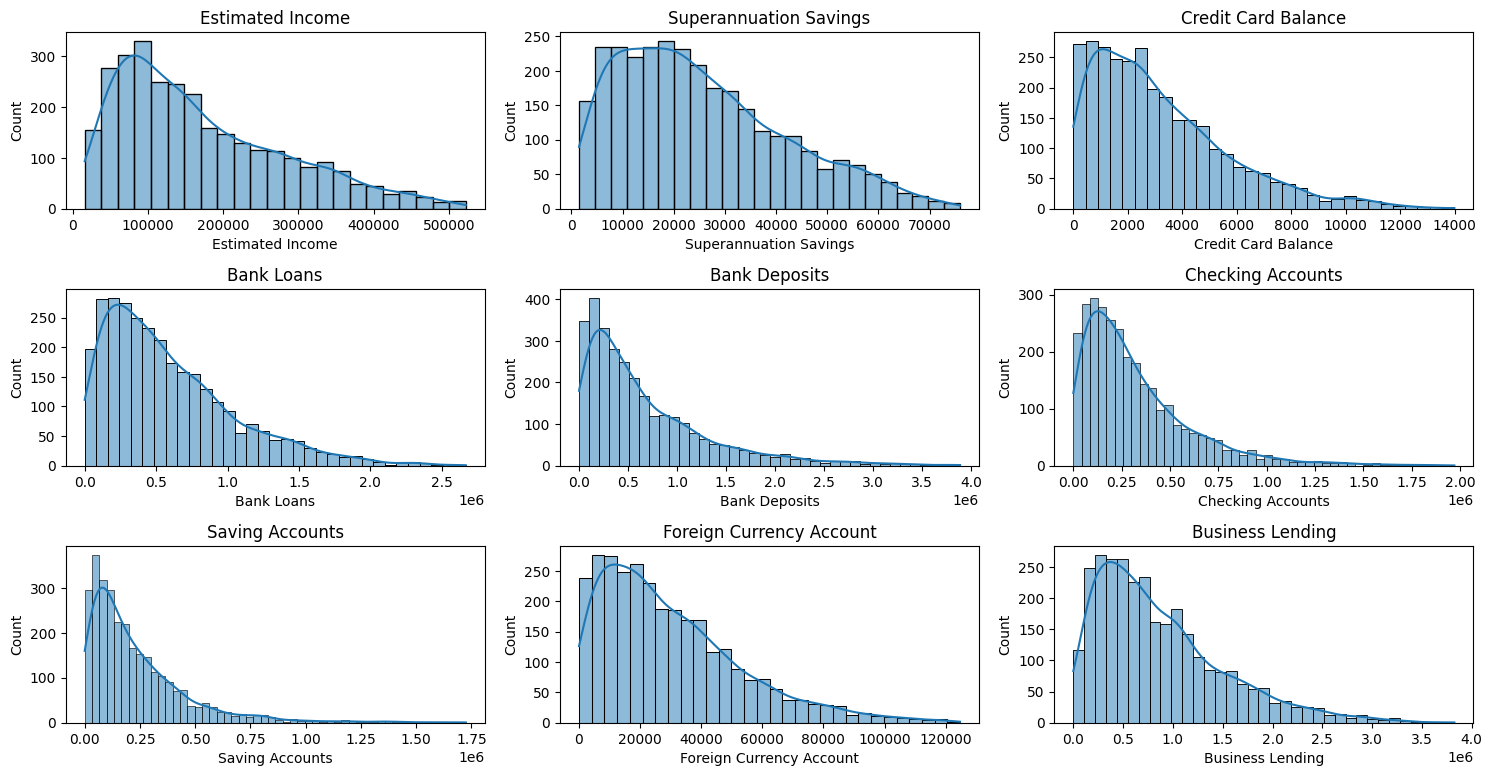

In [33]:
#Numerical univariate analysis
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

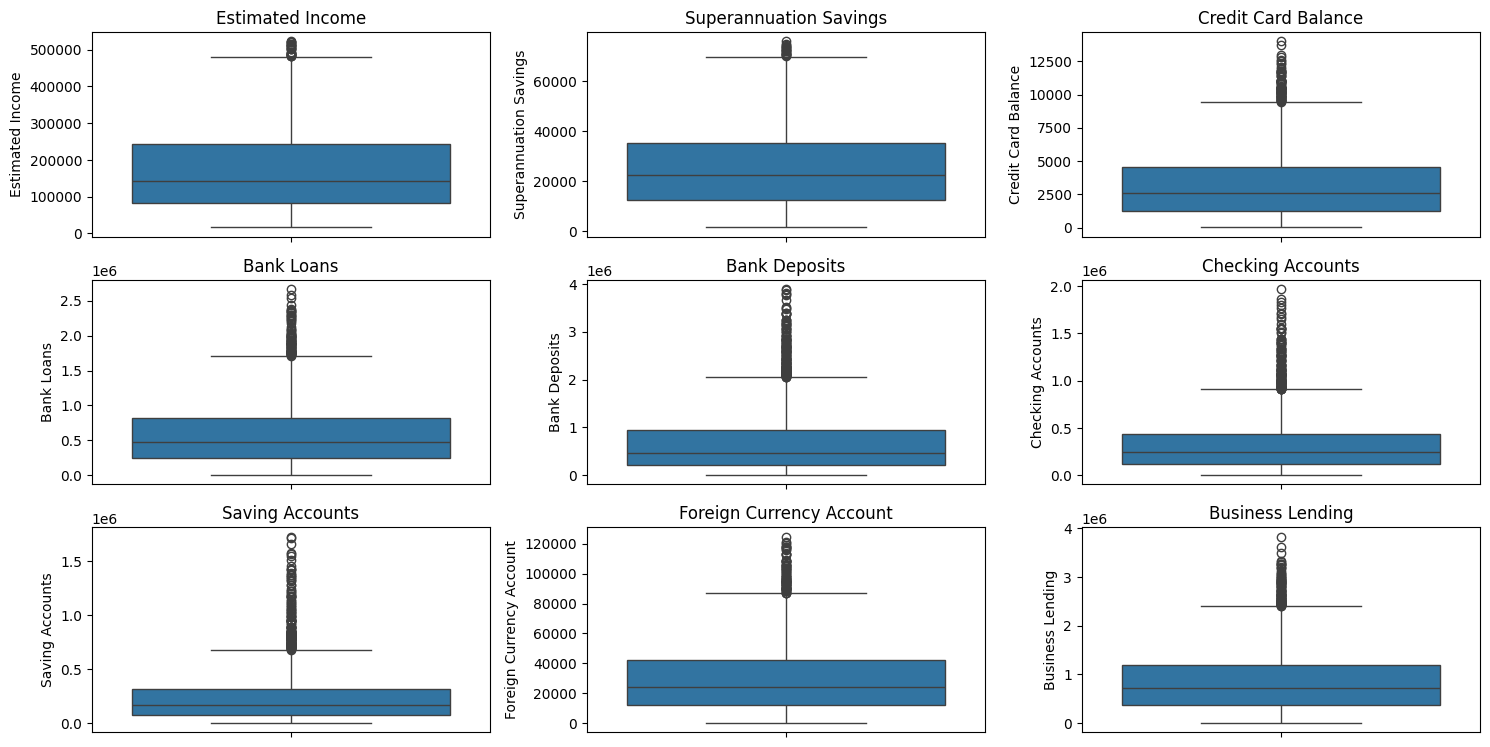

In [34]:
#Outlier analysis
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [35]:
#Coorelation matrix
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,Estimated Income,Superannuation Savings,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending
Estimated Income,1.000000,0.374802,0.298527,0.329926,0.260332,0.291412,0.261299,0.306999,0.328531
Superannuation Savings,0.374802,1.000000,0.225562,0.241457,0.174084,0.198188,0.177132,0.228103,0.264919
Credit Card Balance,0.298527,0.225562,1.000000,0.369509,0.383877,0.298672,0.284696,0.357720,0.351063
Bank Loans,0.329926,0.241457,0.369509,1.000000,0.373155,0.292082,0.268882,0.364391,0.417095
Bank Deposits,0.260332,0.174084,0.383877,0.373155,1.000000,0.844278,0.754744,0.406347,0.441298
Checking Accounts,0.291412,0.198188,0.298672,0.292082,0.844278,1.000000,0.459509,0.312651,0.355904
Saving Accounts,0.261299,0.177132,0.284696,0.268882,0.754744,0.459509,1.000000,0.311465,0.307550
Foreign Currency Account,0.306999,0.228103,0.357720,0.364391,0.406347,0.312651,0.311465,1.000000,0.369749
Business Lending,0.328531,0.264919,0.351063,0.417095,0.441298,0.355904,0.307550,0.369749,1.000000


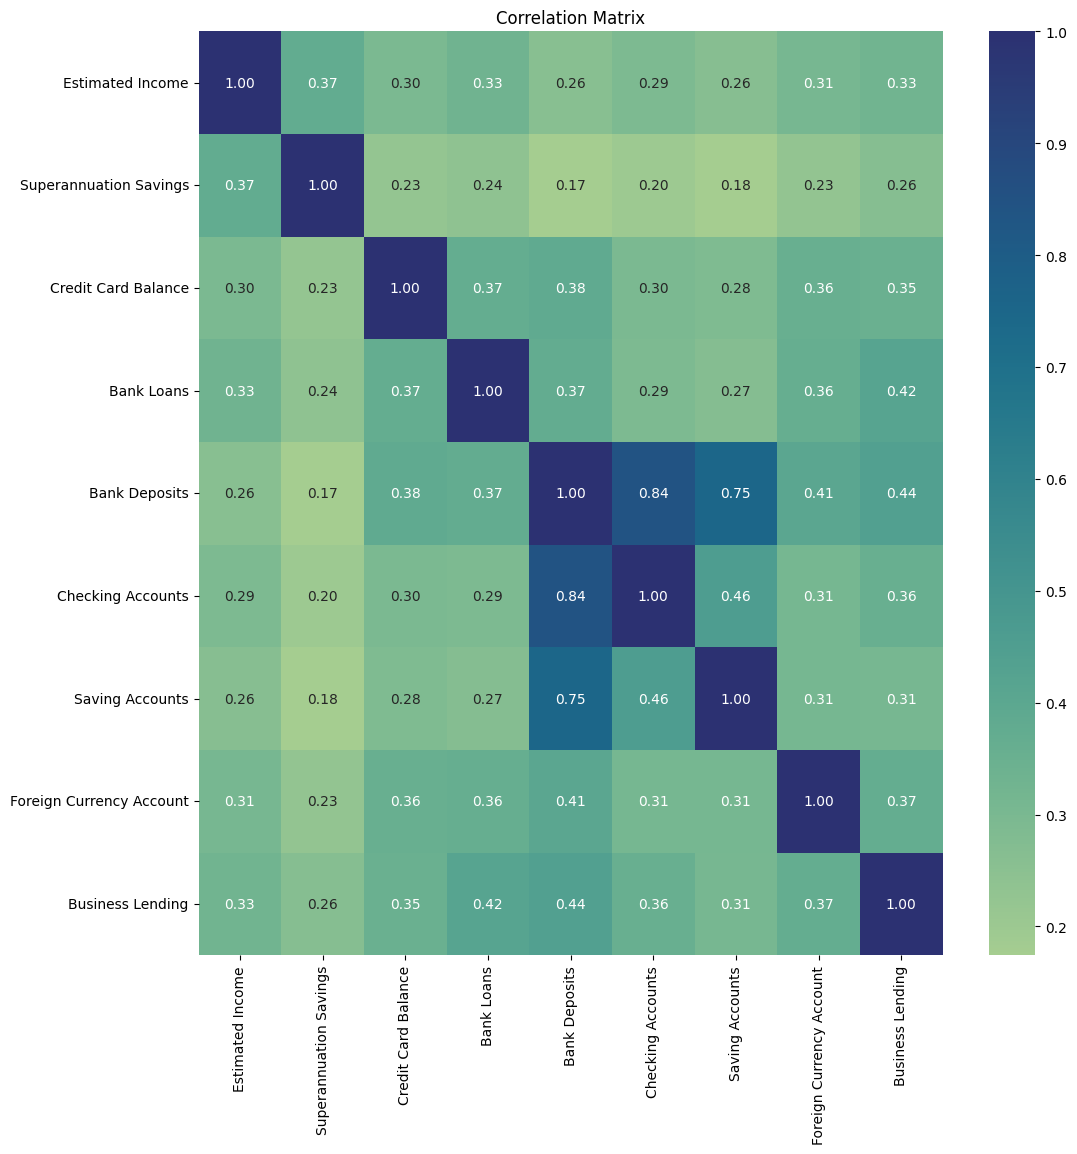

In [36]:
#Corelation Heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix,annot=True,cmap='crest',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [37]:
#Final data check
print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Shape: (3000, 26)

Missing Values:
ï»¿Client ID                0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
Income Band                 0
dtype: int64

Duplicate Rows:
0


EDA Insights:
Insight 1 — Bank Deposits
The strongest positive correlations are observed between Bank Deposits and Checking Accounts, Saving Accounts, and Foreign Currency Account.
This indicates that customers who maintain higher balances in bank deposits tend to maintain substantial funds across other account types as well.

Insight 2 — Income
The Income Band classification divides customers into Low, Medium, and High income groups, making it easier to analyze customers according to their estimated income.

Insight 3 — Customer Characteristics
Categorical analysis provides information about the distribution of customers based on:
Nationality
Occupation
Loyalty Classification
Fee Structure
Risk Weighting
Properties Owned
Number of Credit Cards

Insight 4 — Financial Variables
The histograms show the distribution of financial variables such as:
Estimated Income
Bank Loans
Bank Deposits
Credit Card Balance
Checking Accounts
Saving Accounts
Business Lending

Insight 5 — Data Quality
Missing-value, duplicate, datatype, and outlier checks help ensure that the data is appropriate for further analysis.